# Setup & Environment Configuration
Configure environment, paths, and load

In [1]:
# Setup & Imports
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Configuration for Editorial/Journalism Quality
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

print(f"Project root resolved to: {PROJECT_ROOT}")

Project root resolved to: C:\Users\JYOTSNA\Documents\fiscal-ledger


Load Analyzed Panel Data

In [2]:
# Ingest Parquet Dataset from Notebook 01
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "global_budgets_analyzed.parquet"
df = pd.read_parquet(DATA_PATH)

# Add Historical Eras categorical column
def assign_era(year):
    if year <= 1945:
        return '1. WWII & Pre-War (1936-1945)'
    elif year <= 1991:
        return '2. Cold War Era (1946-1991)'
    elif year <= 2019:
        return '3. Globalization & Post-Cold War (1992-2019)'
    else:
        return '4. Modern Era & Crises (2020-2026)'

df['Historical_Era'] = df['Year'].apply(assign_era)

print(f"Loaded {len(df)} rows across {df['Country'].nunique()} countries.")
df.head(3)

Loaded 3654 rows across 45 countries.


,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,...,Interest_Payments_Amount_Billions_USD_Calculated,Infrastructure_Amount_Billions_USD_Calculated,Agriculture_Amount_Billions_USD_Calculated,State_Transfers_Amount_Billions_USD_Calculated,Social_Welfare_Amount_Billions_USD_Calculated,Administration_and_Others_Amount_Billions_USD_Calculated,Social_Total_Percentage,Guns_Butter_Ratio,Guns_Butter_Index_Normalized,Historical_Era
0,1946,5.78,15.4,17.82,8.65,1.552,13.09,7.85,10.47,10.47,...,0.134248,0.203157,0.121832,0.162494,0.162494,0.162494,43.69,0.132296,-0.766323,2. Cold War Era (1946-1991)
1,1947,5.78,15.4,17.82,8.65,1.629,13.09,7.85,10.47,10.47,...,0.140909,0.213236,0.127877,0.170556,0.170556,0.170556,43.69,0.132296,-0.766323,2. Cold War Era (1946-1991)
2,1948,5.78,15.4,17.82,8.65,1.711,13.09,7.85,10.47,10.47,...,0.148002,0.223970,0.134314,0.179142,0.179142,0.179142,43.69,0.132296,-0.766323,2. Cold War Era (1946-1991)


# Global Trend — Aggregate Defense vs. Social Spending (1936–2026)
Global Trend Analysis: Plot the 90-year evolution of Defense % vs. Combined Social % (Health + Education + Welfare).

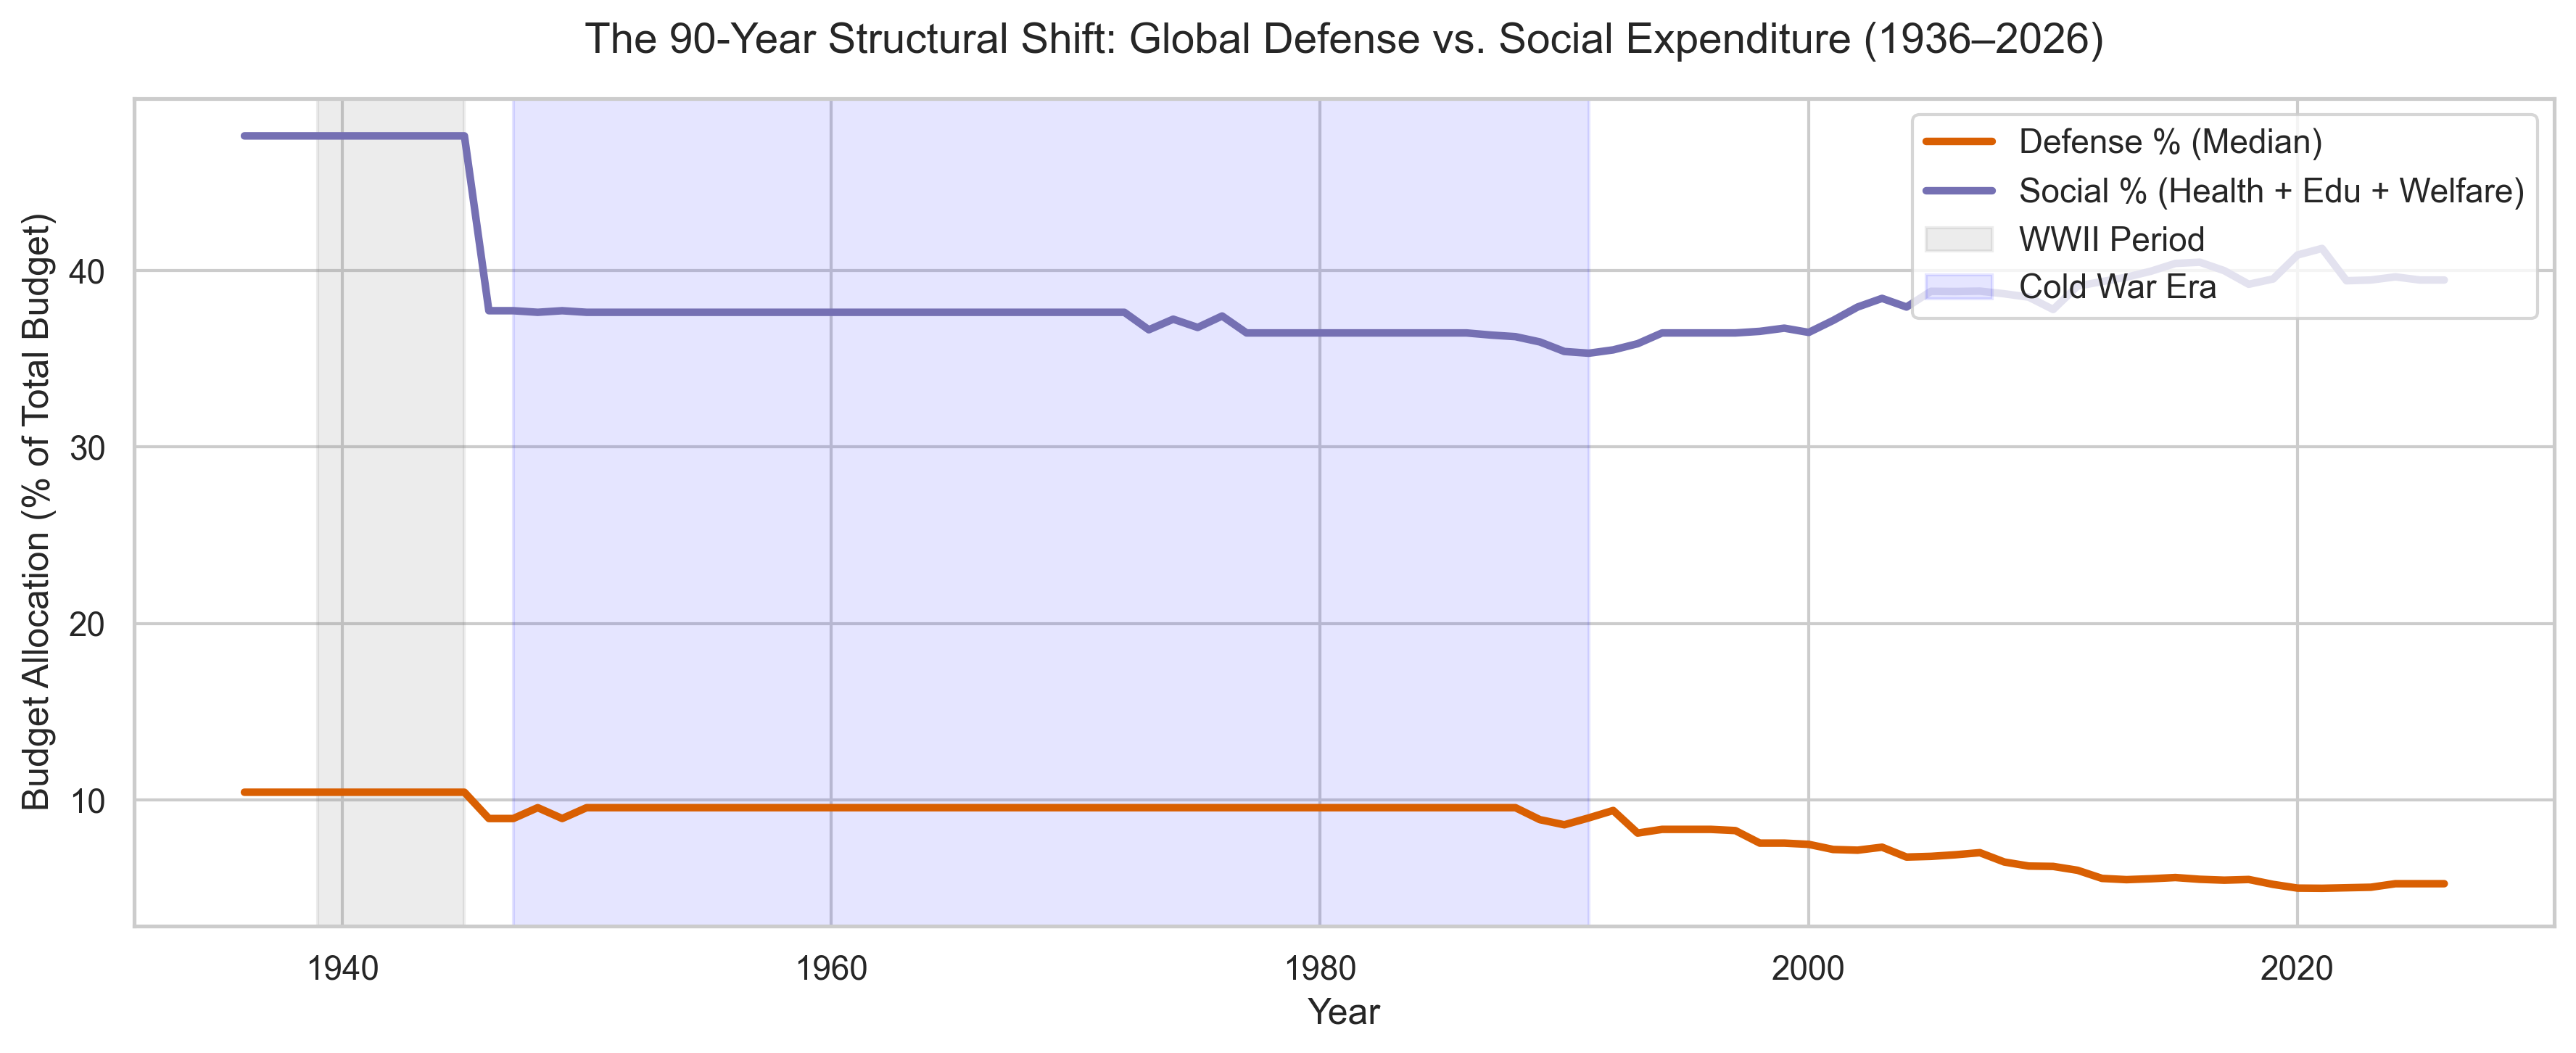

In [3]:
# Calculate yearly medians across all countries
annual_medians = df.groupby('Year')[['Defense_Percentage', 'Social_Total_Percentage', 'Guns_Butter_Ratio']].median().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Defense and Social Percentages
ax1.plot(annual_medians['Year'], annual_medians['Defense_Percentage'], color='#d95f02', linewidth=2.5, label='Defense % (Median)')
ax1.plot(annual_medians['Year'], annual_medians['Social_Total_Percentage'], color='#7570b3', linewidth=2.5, label='Social % (Health + Edu + Welfare)')
ax1.set_ylabel("Budget Allocation (% of Total Budget)", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)

# Highlight Key Historical Epochs
ax1.axvspan(1939, 1945, color='gray', alpha=0.15, label='WWII Period')
ax1.axvspan(1947, 1991, color='blue', alpha=0.1, label='Cold War Era')

plt.title("The 90-Year Structural Shift: Global Defense vs. Social Expenditure (1936–2026)", fontsize=14, pad=15)
ax1.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Save output
plt.savefig(PROJECT_ROOT / "figures" / "02_global_spending_trends.png")
plt.show()

### Key Policy Observation: The Great Inversion
* **Macroeconomic Realignment**: Prior to the late 1990s, global defense spending retained a sustained baseline relative to social spending. Post-1990, a structural divergence occurred: median global defense allocation continuously declined from $\sim 10\%$ toward $\sim 5\%$, while median social spending (Health, Education, and Welfare combined) expanded past $40\%$.
* **The Peace Dividend**: The transition away from the Cold War enabled sovereign states to reallocate fiscal resources along the Production Possibilities Frontier (PPF) away from security guarantees toward long-term human capital investments.

Macroeconomic Perspective: Production Possibilities Frontier
In macroeconomics, the choice between military security and domestic welfare is modeled as a Production Possibilities Curve (PPC). Allocating resources to "Guns" directly reduces the budget available for "Butter" along the opportunity cost curve.

# Distribution of Guns-vs-Butter Ratio Across Eras
Distribution Across Eras: Compare spending priorities across four key geopolitical eras using box plots/violin plots.

C:\Users\JYOTSNA\AppData\Local\Temp\ipykernel_24364\4230329098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


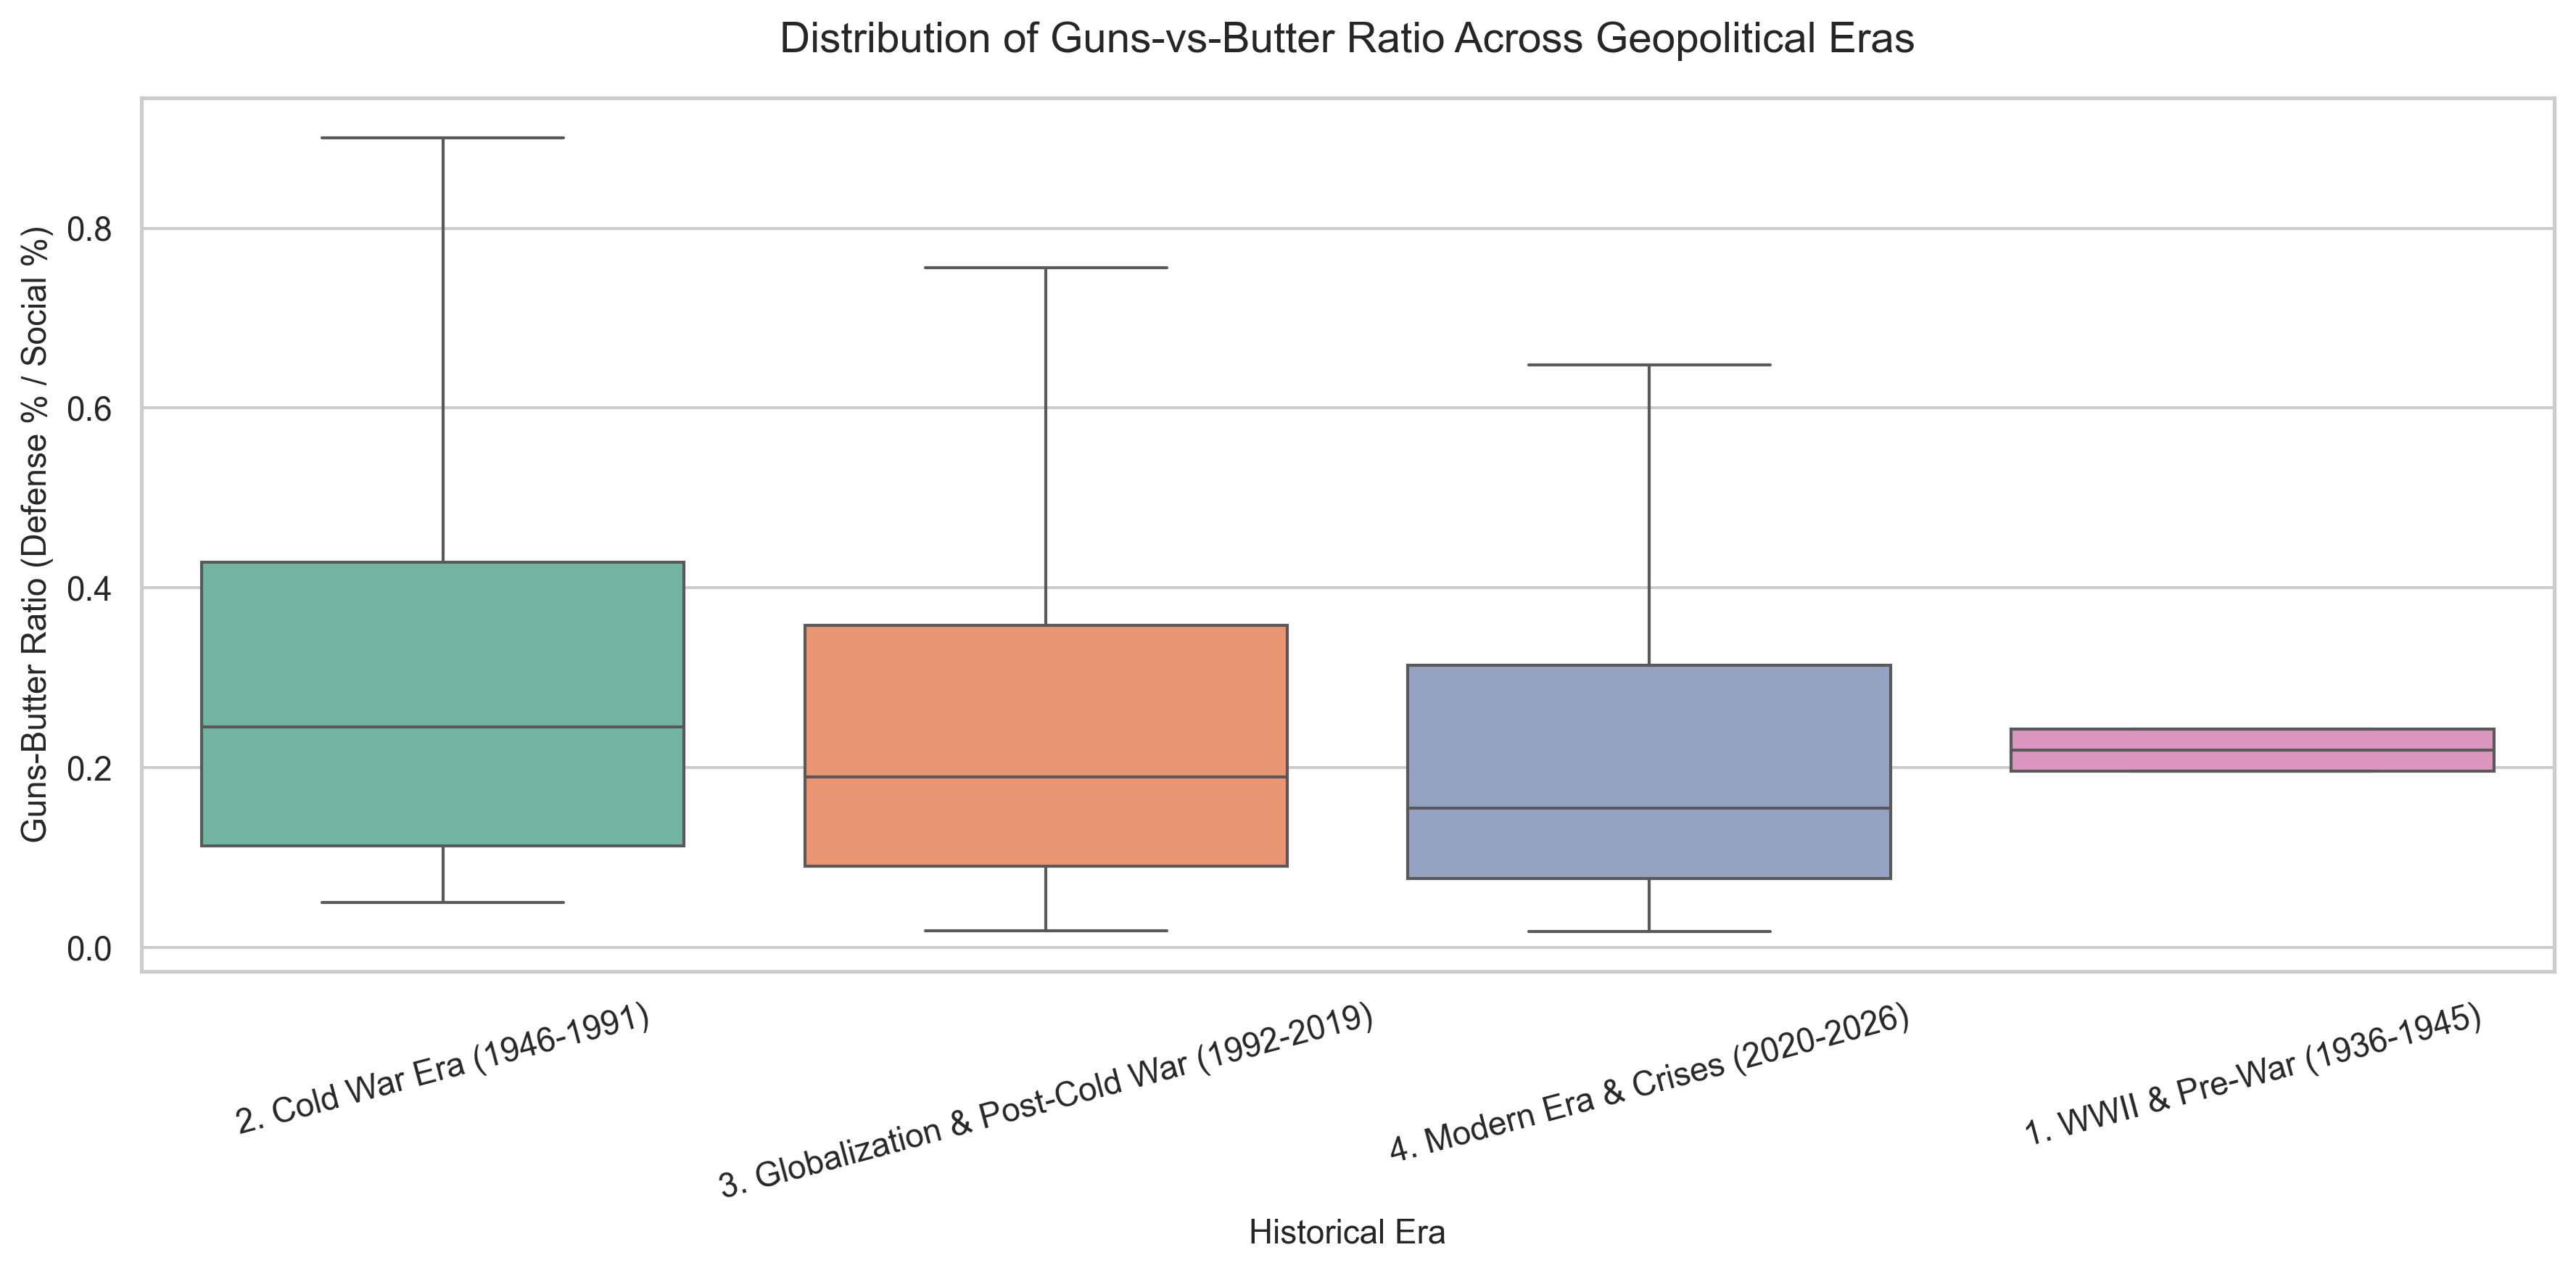

In [4]:
# Era Comparison via Boxplots
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df, 
    x='Historical_Era', 
    y='Guns_Butter_Ratio', 
    palette='Set2', 
    showfliers=False # Hide extreme outliers for readable scaling
)

plt.title("Distribution of Guns-vs-Butter Ratio Across Geopolitical Eras", fontsize=14, pad=15)
plt.xlabel("Historical Era", fontsize=11)
plt.ylabel("Guns-Butter Ratio (Defense % / Social %)", fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "figures" / "02_guns_butter_era_distribution.png")
plt.show()

### Key Policy Observation: Historical Era Volatility
* **Cold War Intensity (1946–1991)**: Features the highest median ratio ($\sim 0.25$) and the widest distribution tail (reaching up to $0.90$), reflecting acute military build-ups among strategic allies and rivals.
* **Globalization & Post-Cold War (1992–2019)**: Shows a compressed interquartile range and lower median ratio ($\sim 0.18$), illustrating widespread fiscal shift toward domestic welfare state expansion.
* **Modern Era & Crises (2020–2026)**: Demonstrates a low median ratio driven by massive COVID-19 relief and health stimulus, though upper whiskers indicate regional defense re-armament efforts.

# Heatmap Comparison — Top Geopolitical Players Over Time
The Guns-vs-Butter Ratio Matrix: Heatmap comparing top world powers and regional drivers over time.

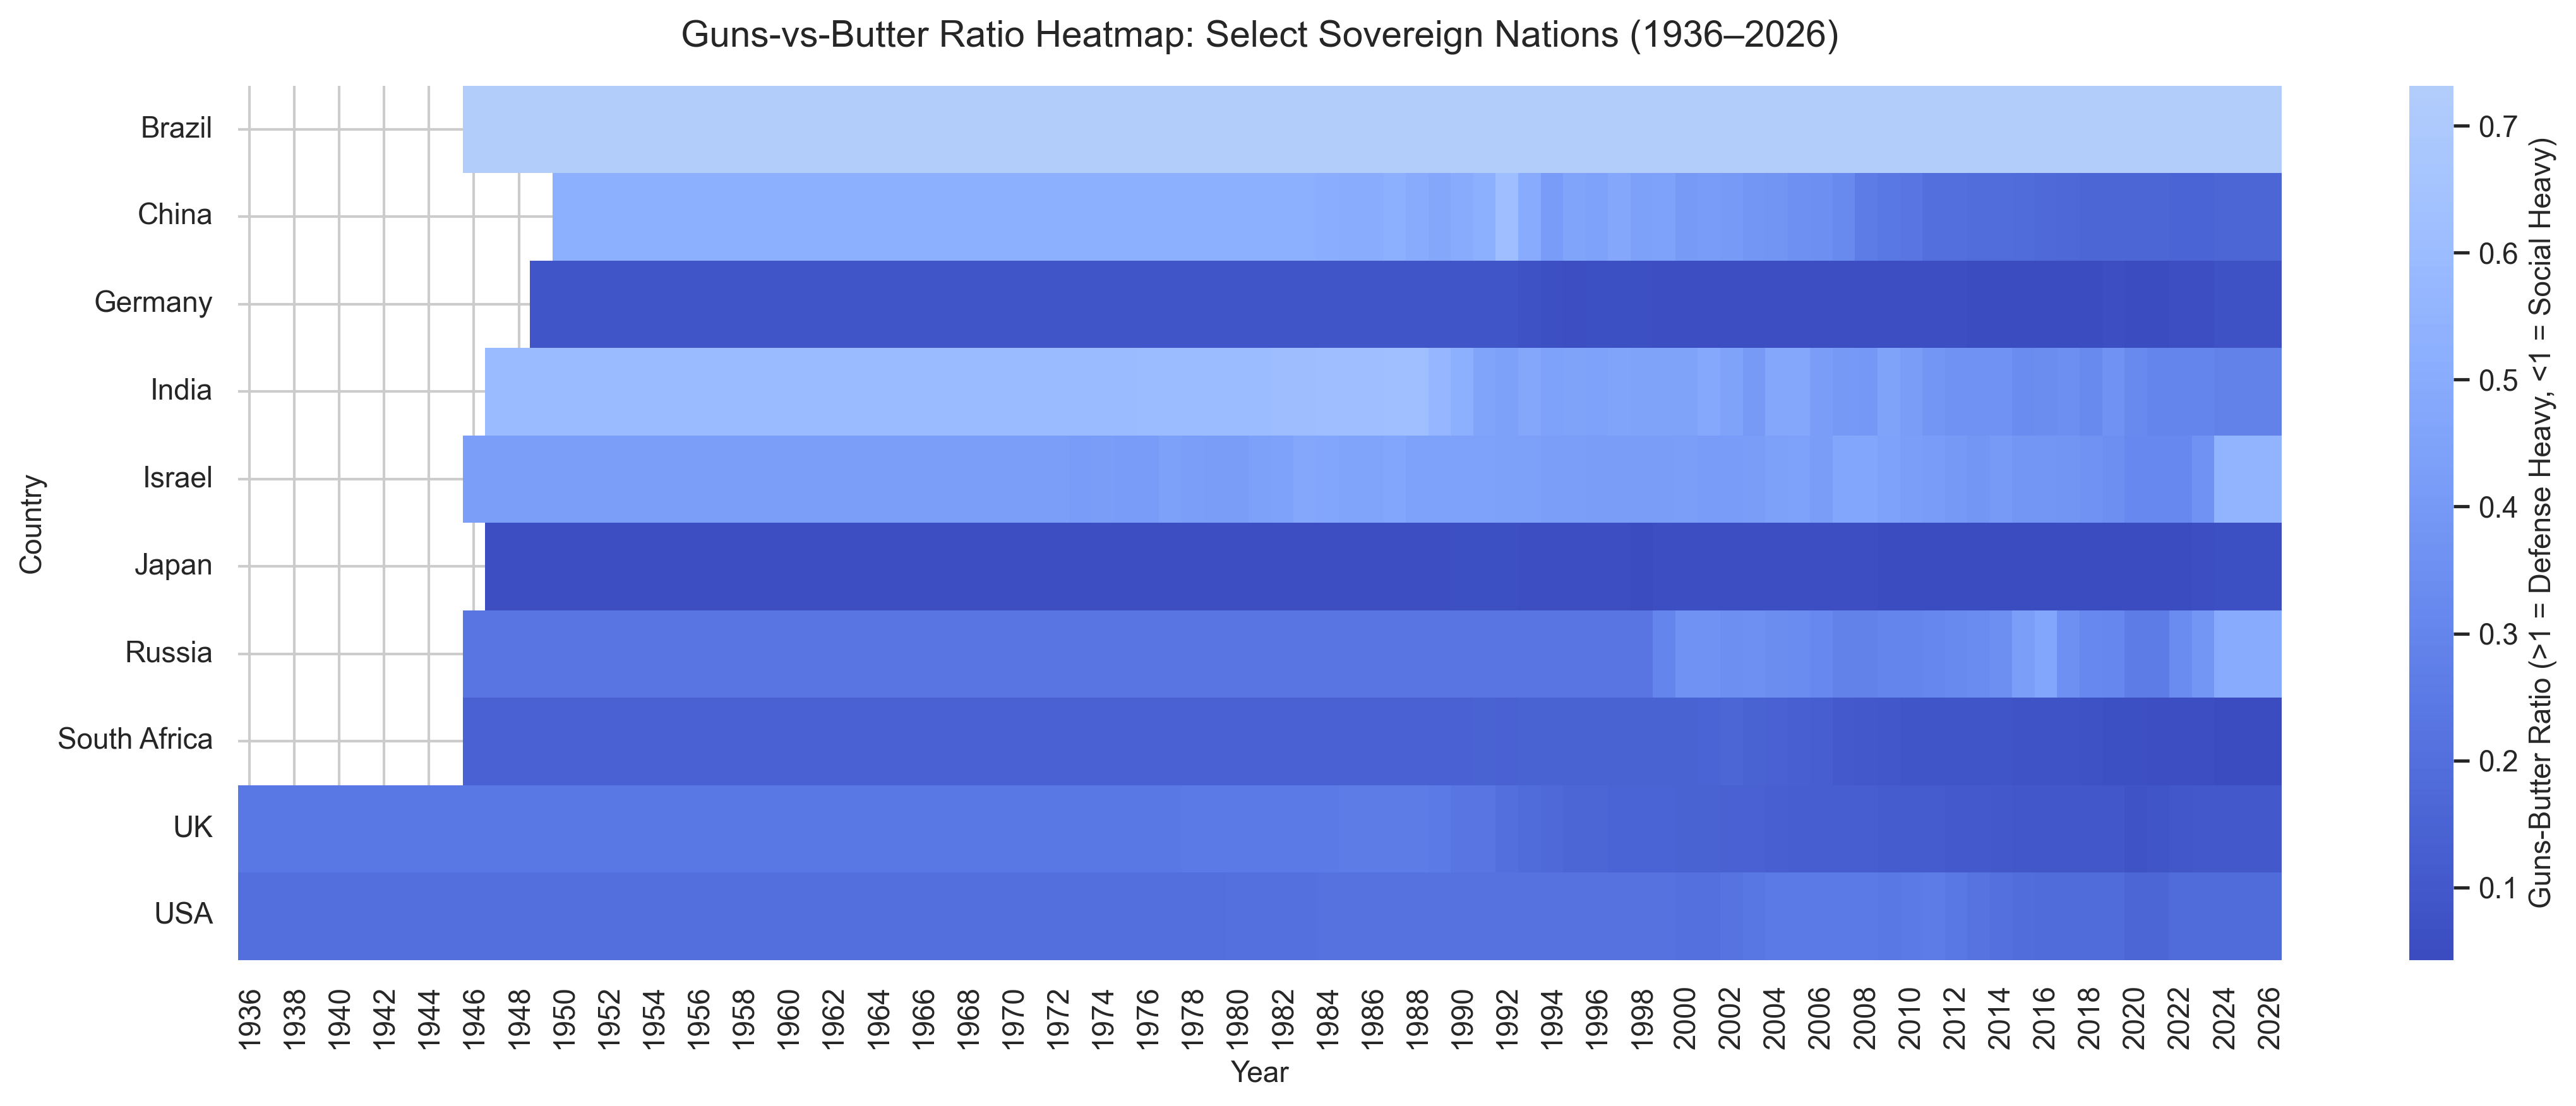

In [5]:
# Select key countries for visual matrix
selected_countries = [
    'USA', 'UK', 'Germany', 'Russia', 
    'China', 'India', 'Japan', 'Brazil', 'South Africa', 'Israel'
]

# Filter and create pivot table
df_sub = df[df['Country'].isin(selected_countries)]
pivot_gb = df_sub.pivot(index='Country', columns='Year', values='Guns_Butter_Ratio')

plt.figure(figsize=(15, 6))
sns.heatmap(
    pivot_gb, 
    cmap='coolwarm', 
    center=1.0, 
    cbar_kws={'label': 'Guns-Butter Ratio (>1 = Defense Heavy, <1 = Social Heavy)'}
)

plt.title("Guns-vs-Butter Ratio Heatmap: Select Sovereign Nations (1936–2026)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Country", fontsize=11)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "figures" / "02_country_ratio_heatmap.png")
plt.show()

### Key Policy Observation: Sovereign Heterogeneity & Demilitarization
* **Demilitarization Trajectories**: Modern post-WWII demilitarized states—such as Japan and Germany—exhibit consistently low Guns-to-Butter ratios (darker blue hue, ratio $< 0.15$) across nearly all post-war decades.
* **Persistent Security States**: In contrast, nations subject to active geopolitical friction or superpower status (e.g., USA, UK, Israel, Russia) maintain elevated defense ratios over extended durations. 
* **Emerging Market Transition**: Developing economies (e.g., India, China) show a gradual color shift in the 1990s and 2000s, reflecting expanding social safety net allocations as their formal tax bases scaled.

# Trajectory Deep Dive — Comparing 4 Divergent Fiscal Paths
Key Country Trajectories: Deep-dive line plots comparing distinct fiscal paths (e.g., US, Germany, Japan, Brazil, India).

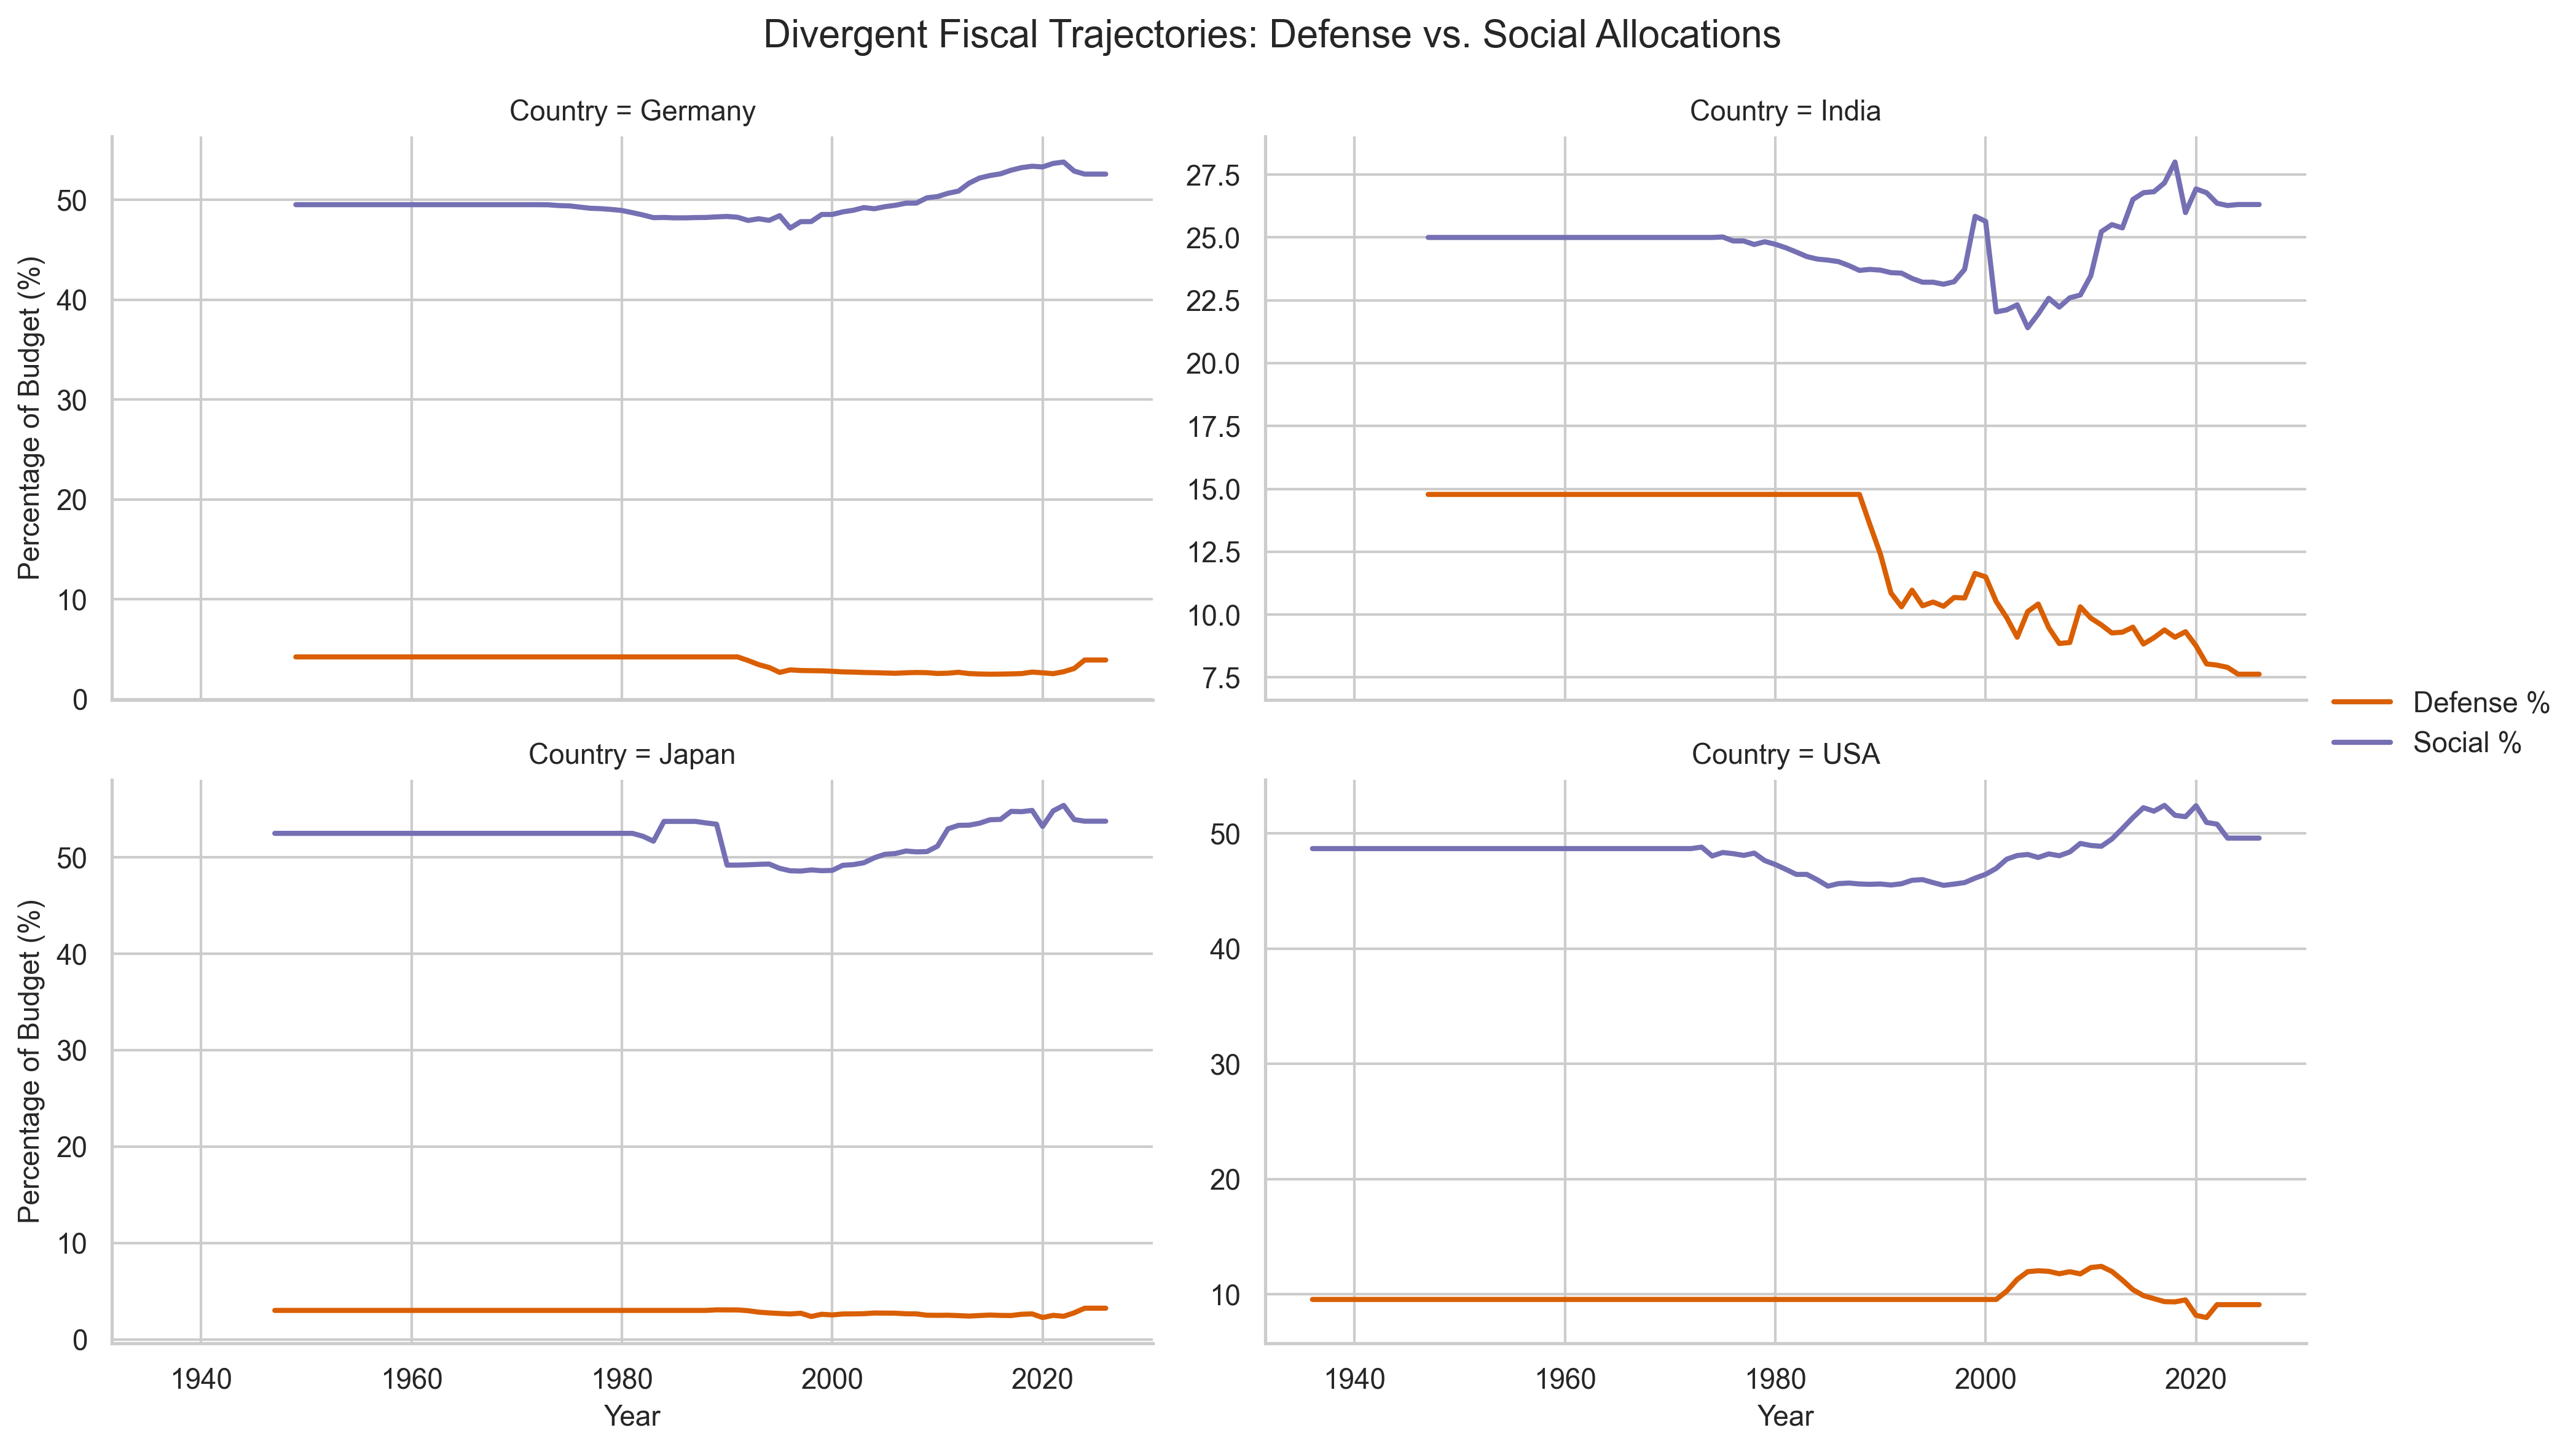

In [6]:
# Line plot for 4 contrasting country archetypes
focus_nations = ['USA', 'Germany', 'Japan', 'India']
df_focus = df[df['Country'].isin(focus_nations)]

g = sns.FacetGrid(df_focus, col='Country', col_wrap=2, height=4, aspect=1.6, sharey=False)
g.map_dataframe(sns.lineplot, x='Year', y='Defense_Percentage', color='#d95f02', label='Defense %', linewidth=2)
g.map_dataframe(sns.lineplot, x='Year', y='Social_Total_Percentage', color='#7570b3', label='Social %', linewidth=2)

g.add_legend()
g.set_axis_labels("Year", "Percentage of Budget (%)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Divergent Fiscal Trajectories: Defense vs. Social Allocations", fontsize=15)

plt.savefig(PROJECT_ROOT / "figures" / "02_divergent_country_paths.png")
plt.show()

### Key Policy Observation: Demilitarization vs. Emerging Market Expansion
* **Demilitarized Stability**: Both Germany and Japan maintain stable, elevated social expenditure baselines ($> 50\%$) accompanied by suppressed, flat defense allocations ($< 5\%$).
* **Emerging Market Scaling (India)**: India shows a structural shift after the 1990s liberalization—defense spending trends down from $15\%$ to under $7.5\%$, while social infrastructure investments surge from $22\%$ toward $27.5\%$.
* **Superpower Dynamics (USA)**: The US reflects a stable defense baseline with episodic expansion during post-9/11 defense mobilizations before settling back into a high social allocation trajectory.

The Great Inversion: Global priorities shifted drastically from military dominance during WWII/Cold War toward expanding social safety nets (health, education, welfare) in the late 1990s and 2000s.

Demilitarization Effects: Modern demilitarized states like post-WWII Japan and Germany maintain low Guns-Butter ratios compared to persistent security states like the US or Israel.

Emerging Market Expansion: Developing nations exhibit growing social spending percentages as tax bases formalize and healthcare infrastructure scales.